#Import modules

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

#Data

In [3]:
tissues = pd.read_excel('drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/Metabolite_prediction_ML_model_comparison.xlsx', sheet_name = 0, index_col = 0)
tissues

,Ridge,Lasso,Elastic Net,Random forest regressor,XGBoost regressor,LightGBM regressor,MLP regressor,Ensemble
Hyperparameters,a=450,a=1,"a=1, l1=0.5","estimators=500, depth=30","estimators=100, depth=5, subsample=1","estimators=100, depth=5, leaves=30","activation': 'tanh', alpha: 10, batch_size: 32...",ElasticNet + Random forest regressor -> Ridge
R-squared,0.544084,0.547389,0.547258,0.657575,0.613381,0.629387,0.572182,0.784151
Average R-squared score (10-fold CV),0.604545,0.605343,0.604453,0.515999,0.520251,0.594791,0.610574,0.598814
Mean Squared Error (MSE),2.81905,2.799342,2.796079,2.380259,2.752721,2.599058,2.537843,1.371924
Average negative MSE (10-fold CV),-2.398192,-2.405626,-2.39639,-2.734335,-2.778128,-2.64383,-2.299273,-2.271989
Root Mean Squared Error (RMSE),1.679003,1.673124,1.672148,1.542809,1.659133,1.61216,1.593061,1.171292
Mean Absolute Error (MAE),1.140605,1.137271,1.136796,1.073588,1.138256,1.115882,1.129974,0.752474
Median Absolute Error (MedAE),0.754858,0.753519,0.754222,0.778569,0.80387,0.71684,0.825254,0.484125
Mean absolute percentage error,5.574727,5.555949,5.554989,5.54387,5.794381,5.452676,5.522739,3.7808
Spearman's coeff,0.91,0.91,0.91,0.92,0.91,0.91,0.92,0.96


In [4]:
cells = pd.read_excel('drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/Metabolite_prediction_ML_model_comparison.xlsx', sheet_name = 1, index_col = 0)
cells

,Ridge,Lasso,Elastic Net,Random forest regressor,XGBoost regressor,LightGBM regressor,MLP regressor,Ensemble
Hyperparameters,a=6500,a=1,"a=1, l1=0.5","estimators=500, depth=20","estimators=100, depth=5, subsample=1","estimators=100, depth=5, leaves=30","activation = 'tanh',\n ...",ElasticNet + Random forest regressor -> Ridge
R-squared,0.176608,0.147665,0.16839,0.124615,0.003934,0.095284,0.11411,0.6522
Average R-squared score (10-fold CV),0.153423,0.126118,0.145295,0.109711,0.01582,0.080073,0.079621,0.640258
Mean Squared Error (MSE),0.109655,0.114474,0.111238,0.117923,0.130505,0.12094,0.118601,0.046804
Average negative MSE (10-fold CV),-0.113614,-0.118875,-0.1154,-0.121331,-0.133478,-0.123951,-0.122939,-0.045416
Root Mean Squared Error (RMSE),0.331141,0.33834,0.333524,0.343399,0.361255,0.347764,0.344386,0.216342
Mean Absolute Error (MAE),0.240288,0.244387,0.241258,0.246103,0.261835,0.251854,0.248632,0.134489
Median Absolute Error (MedAE),0.195264,0.197455,0.194667,0.196648,0.210569,0.202753,0.200693,0.085988
Mean absolute percentage error,4.144966,4.216379,4.16191,4.24744,4.515473,4.344099,4.27367,2.317474
Spearman's coeff,0.41,0.37,0.4,0.35,0.24,0.32,0.33,0.8


#Plots

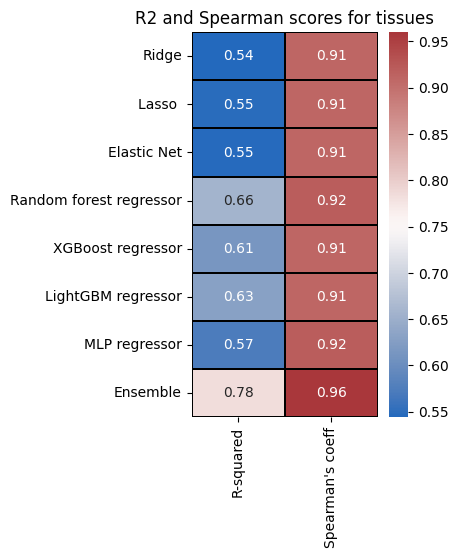

In [5]:
plt.figure(figsize = (3, 5))
sns.heatmap(tissues.iloc[[1, -1]].T.apply(pd.to_numeric, errors='coerce'), cmap = sns.color_palette("vlag", as_cmap=True), linewidths = 0.05, linecolor='black', annot = True)
plt.title('R2 and Spearman scores for tissues')
plt.savefig('drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/Plots/heatmap_r2_spearman_tissues.svg', bbox_inches = 'tight')

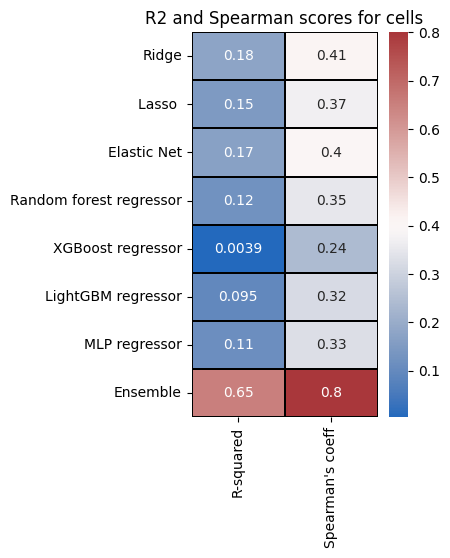

In [6]:
plt.figure(figsize = (3, 5))
sns.heatmap(cells.iloc[[1, -1]].T.apply(pd.to_numeric, errors='coerce'), cmap = sns.color_palette("vlag", as_cmap=True), linewidths = 0.05, linecolor='black', annot = True)
plt.title('R2 and Spearman scores for cells')
plt.savefig('drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/Plots/heatmap_r2_spearman_cells.svg', bbox_inches = 'tight')

In [7]:
tissues_1 = tissues.iloc[2:9, :]
tissues_1

,Ridge,Lasso,Elastic Net,Random forest regressor,XGBoost regressor,LightGBM regressor,MLP regressor,Ensemble
Average R-squared score (10-fold CV),0.604545,0.605343,0.604453,0.515999,0.520251,0.594791,0.610574,0.598814
Mean Squared Error (MSE),2.81905,2.799342,2.796079,2.380259,2.752721,2.599058,2.537843,1.371924
Average negative MSE (10-fold CV),-2.398192,-2.405626,-2.39639,-2.734335,-2.778128,-2.64383,-2.299273,-2.271989
Root Mean Squared Error (RMSE),1.679003,1.673124,1.672148,1.542809,1.659133,1.61216,1.593061,1.171292
Mean Absolute Error (MAE),1.140605,1.137271,1.136796,1.073588,1.138256,1.115882,1.129974,0.752474
Median Absolute Error (MedAE),0.754858,0.753519,0.754222,0.778569,0.80387,0.71684,0.825254,0.484125
Mean absolute percentage error,5.574727,5.555949,5.554989,5.54387,5.794381,5.452676,5.522739,3.7808


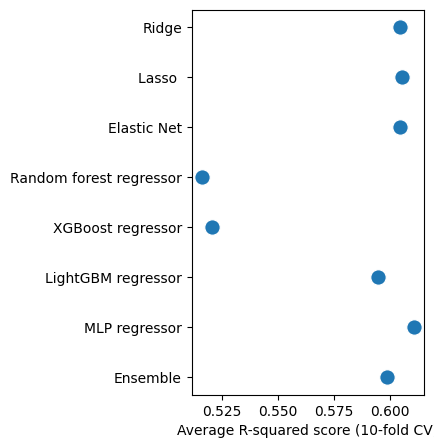

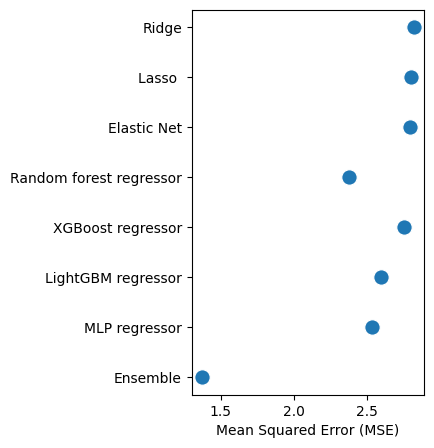

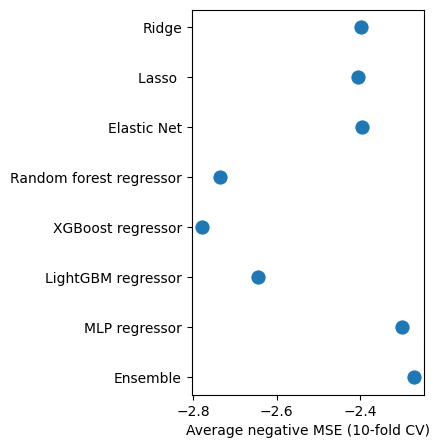

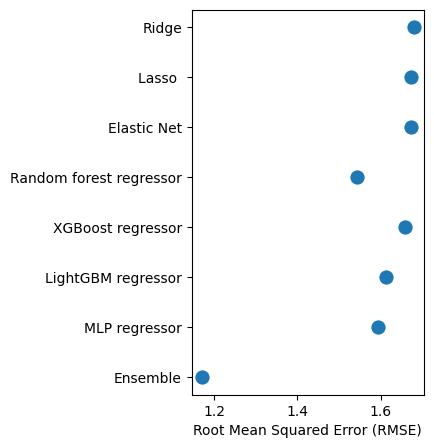

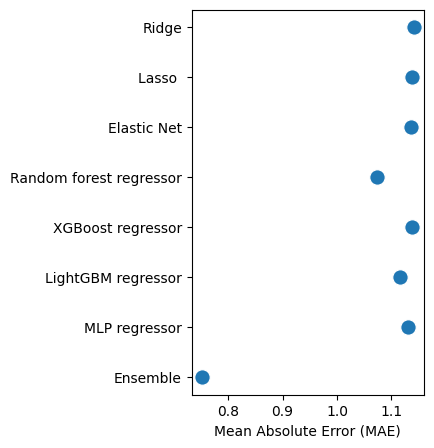

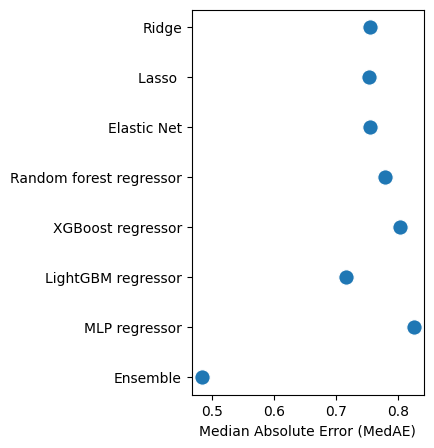

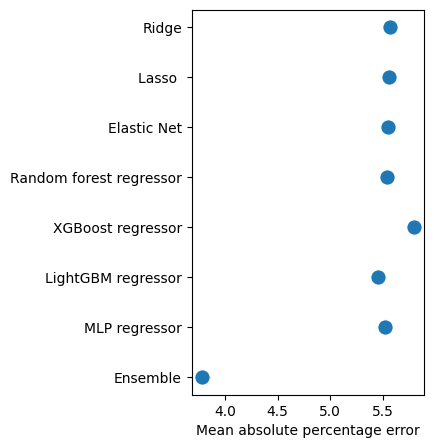

In [8]:
for param in tissues_1.index:
  plt.figure(figsize = (3, 5))
  sns.scatterplot(data = tissues_1.loc[param].reset_index(), y = 'index', x = param, s = 125)
  plt.ylabel('')
  plt.savefig(f'drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/Plots/{param}_tissues.svg', bbox_inches = 'tight')
  plt.show()

In [9]:
cells_1 = cells.iloc[2:9, :]
cells_1

,Ridge,Lasso,Elastic Net,Random forest regressor,XGBoost regressor,LightGBM regressor,MLP regressor,Ensemble
Average R-squared score (10-fold CV),0.153423,0.126118,0.145295,0.109711,0.01582,0.080073,0.079621,0.640258
Mean Squared Error (MSE),0.109655,0.114474,0.111238,0.117923,0.130505,0.12094,0.118601,0.046804
Average negative MSE (10-fold CV),-0.113614,-0.118875,-0.1154,-0.121331,-0.133478,-0.123951,-0.122939,-0.045416
Root Mean Squared Error (RMSE),0.331141,0.33834,0.333524,0.343399,0.361255,0.347764,0.344386,0.216342
Mean Absolute Error (MAE),0.240288,0.244387,0.241258,0.246103,0.261835,0.251854,0.248632,0.134489
Median Absolute Error (MedAE),0.195264,0.197455,0.194667,0.196648,0.210569,0.202753,0.200693,0.085988
Mean absolute percentage error,4.144966,4.216379,4.16191,4.24744,4.515473,4.344099,4.27367,2.317474


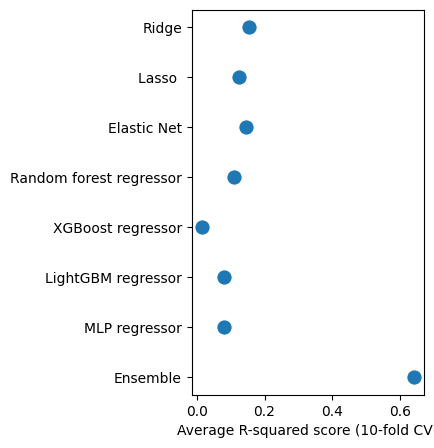

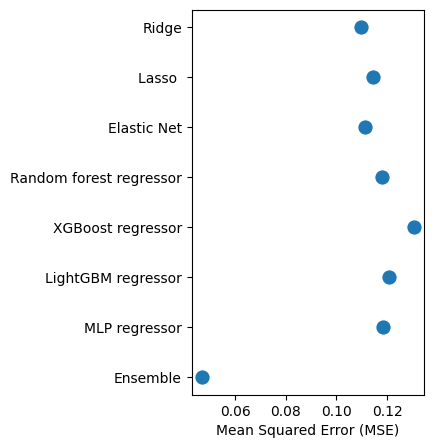

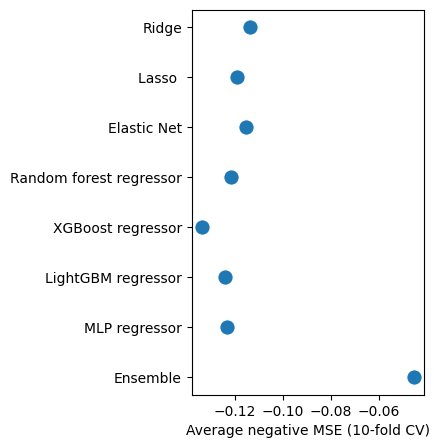

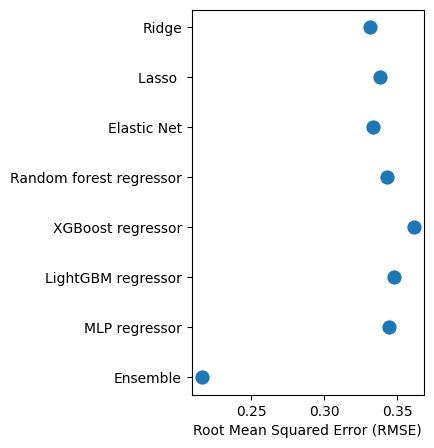

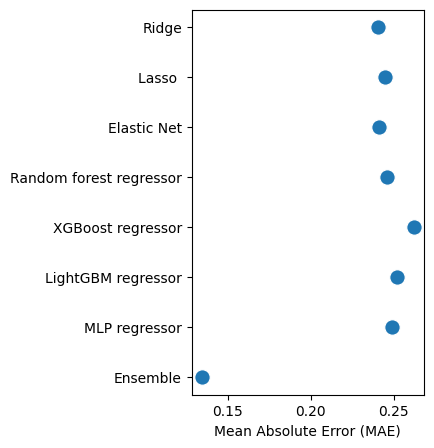

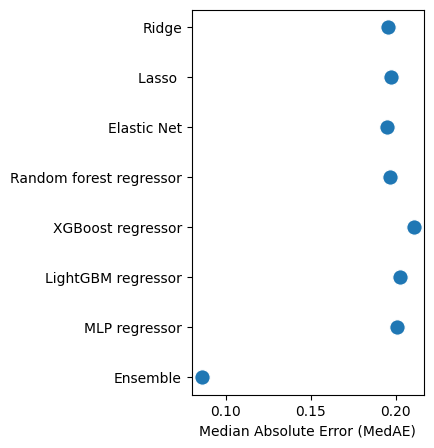

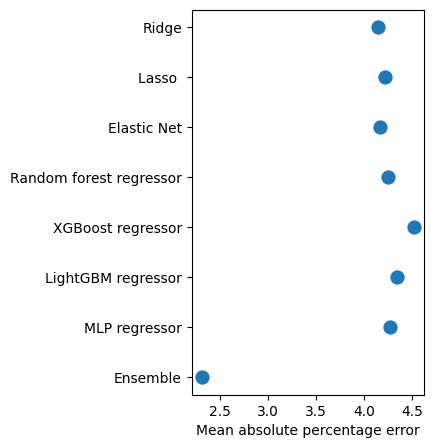

In [10]:
for param in cells_1.index:
  plt.figure(figsize = (3, 5))
  sns.scatterplot(data = cells_1.loc[param].reset_index(), y = 'index', x = param, s = 125)
  plt.ylabel('')
  plt.savefig(f'drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/Plots/{param}_cells.svg', bbox_inches = 'tight')
  plt.show()